In [ ]:
# === STEP 1: Instalasi dan Import Pustaka ===
print("=== STEP 1: Instalasi dan Import Pustaka ===")
!pip install nltk sastrawi transformers scikit-learn imbalanced-learn gensim pyLDAvis tensorflow

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import seaborn as sns

# Library for LDA
import gensim
from gensim import corpora
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Library untuk RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Setting untuk visualisasi pyLDAvis di Colab
pyLDAvis.enable_notebook()
print("Pustaka berhasil diimpor")

# === STEP 2: Unduh Sumber Daya NLTK ===
print("=== STEP 2: Unduh Sumber Daya NLTK ===")
nltk.download('stopwords')
nltk.download('punkt')
print("Sumber daya NLTK berhasil diunduh")

=== STEP 1: Instalasi dan Import Pustaka ===
Pustaka berhasil diimpor
=== STEP 2: Unduh Sumber Daya NLTK ===


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Sumber daya NLTK berhasil diunduh


In [ ]:
# === STEP 3: Membaca Dataset ===
print("=== STEP 3: Membaca Dataset ===")
df = pd.read_excel('/content/ABSA_db_kalimat_komentar.xlsx')
df = df[['kalimat']]
print("Jumlah data:", len(df))
print("Contoh data:")
df.head(10)


=== STEP 3: Membaca Dataset ===
Jumlah data: 6808
Contoh data:


,kalimat
0,"Masya Allah, santri PPM Al-Ikhlash turut menye..."
1,Pemimpin Pondok Al-Ikhlash dengan keren meneri...
2,"Sehat selalu Pak Ustaz, aamiin. Pemimpin Al-Ik..."
3,"Semangat, anak sholeh Ummi. Semoga dimudahkan ..."
4,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz..."
5,"Aamiin, semoga giat dan dilancarkan oleh Allah..."
6,"Aamiin, semoga dimudahkan dan dilancarkan, Nak..."
7,"Masya Allah, semoga dimudahkan, Nak. Alhamduli..."
8,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz..."
9,"Semangat dan sukses, Nak. Aamiin. Alhamdulilla..."


In [ ]:
# === STEP 4: Define Aspect Keywords Dictionary ===
print("=== STEP 4: Define Aspect Keywords Dictionary ===")

# Dictionary untuk menentukan aspek berdasarkan kata kunci
aspect_keywords = {
    'Kualitas Guru': [
        'guru', 'ustaz', 'ustazah', 'pengajar', 'dosen', 'pendidik', 'tenaga pengajar',
        'kiai', 'kyai', 'mudir', 'mudabbir', 'mengajar', 'pembelajaran', 'didik',
        'bimbing', 'ajar', 'pelajaran', 'materi', 'ilmu', 'pengetahuan'
    ],
    'Fasilitas': [
        'fasilitas', 'gedung', 'ruang', 'kelas', 'asrama', 'dormitory', 'kamar',
        'masjid', 'musholla', 'perpustakaan', 'laboratorium', 'lab', 'wifi',
        'internet', 'ac', 'kipas', 'tempat tidur', 'kasur', 'lemari', 'meja',
        'kursi', 'toilet', 'kamar mandi', 'kantin', 'dapur', 'lapangan'
    ],
    'Lingkungan': [
        'lingkungan', 'suasana', 'atmosfer', 'kondisi', 'keadaan', 'tempat',
        'lokasi', 'area', 'sekitar', 'hijau', 'bersih', 'kotor', 'nyaman',
        'tenang', 'ramai', 'sepi', 'aman', 'indah', 'rapi', 'tertib'
    ],
    'Kegiatan Pondok': [
        'kegiatan', 'program', 'acara', 'event', 'agenda', 'jadwal', 'rutinitas',
        'tahfidz', 'tahfiz', 'hafalan', 'quran', 'mengaji', 'sholat', 'salat',
        'dzikir', 'zikir', 'ceramah', 'kajian', 'pengajian', 'tarawih',
        'tahajud', 'subuh', 'isya', 'maghrib', 'dzuhur', 'ashar'
    ],
    'Pembinaan Karakter': [
        'karakter', 'akhlak', 'moral', 'etika', 'sopan', 'santun', 'adab',
        'disiplin', 'tanggung jawab', 'jujur', 'amanah', 'sabar', 'ikhlas',
        'tawadhu', 'rendah hati', 'hormat', 'menghormati', 'patuh', 'taat',
        'pembinaan', 'bina', 'didik', 'bentuk'
    ],
    'Prestasi': [
        'prestasi', 'juara', 'menang', 'kompetisi', 'lomba', 'turnamen',
        'festival', 'olimpiade', 'achievement', 'penghargaan', 'award',
        'medali', 'trophy', 'sertifikat', 'nilai', 'ranking', 'peringkat',
        'terbaik', 'unggul', 'berprestasi'
    ],
    'Akademik': [
        'akademik', 'pelajaran', 'mata pelajaran', 'mapel', 'kurikulum',
        'silabus', 'ujian', 'tes', 'tugas', 'pr', 'nilai', 'rapor',
        'semester', 'kelas', 'tingkat', 'jenjang', 'lulusan', 'alumni',
        'ijazah', 'diploma', 'sarjana'
    ],
    'Motivasi/Spiritual': [
        'motivasi', 'semangat', 'dorongan', 'inspirasi', 'spiritual', 'rohani',
        'iman', 'takwa', 'ibadah', 'doa', 'taqwa', 'keimanan', 'ketaqwaan',
        'religious', 'religius', 'islami', 'syariat', 'sunnah', 'hadist',
        'alquran', 'kitab'
    ],
    'Sosial': [
        'sosial', 'teman', 'sahabat', 'kawan', 'bergaul', 'pergaulan', 'interaksi',
        'komunikasi', 'hubungan', 'relasi', 'kebersamaan', 'gotong royong',
        'tolong menolong', 'kerjasama', 'solidaritas', 'persaudaraan',
        'ukhuwah', 'silaturahmi', 'ramah', 'friendly'
    ],
    'Umum': [
        'pondok', 'pesantren', 'boarding', 'sekolah', 'madrasah', 'institut',
        'universitas', 'kampus', 'yayasan', 'lembaga', 'organisasi', 'institusi'
    ]
}

print("Aspect keywords dictionary telah didefinisikan")


=== STEP 4: Define Aspect Keywords Dictionary ===
Aspect keywords dictionary telah didefinisikan


In [ ]:
def text_cleaning(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\b\d+\b', '', text, flags=re.MULTILINE)
    text = re.sub(r'[:;=]-?[)(DP]', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    return text


In [ ]:
# === STEP 6: Normalisasi Slang ===
print("=== STEP 6: Normalisasi Slang ===")

def normalize_slang(text, slang_dict):
    if not isinstance(text, str):
        return ""
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

# Muat kamus slang (sesuaikan path)
try:
    slang_dict1 = pd.read_excel('/content/SlangwordAFJ.xlsx')
    slang_dict2 = pd.read_excel('/content/slangword_pujangga.xlsx')
    slang_dict3 = pd.read_excel('/content/slangword_ramaprakoso.xlsx')
    slang_dict4 = pd.read_excel('/content/slangword_human.xlsx')  # Tambahan baru

    slang_all = pd.concat([slang_dict1, slang_dict2, slang_dict3, slang_dict4], ignore_index=True)
    slang_all.drop_duplicates(subset='sebelum', keep='last', inplace=True)
    slang_dict = dict(zip(slang_all['sebelum'], slang_all['sesudah']))

    print("Kamus slang berhasil dimuat")
    print(f"Jumlah total entri kamus slang: {len(slang_dict)}")
except:
    print("File kamus slang tidak ditemukan, menggunakan kamus kosong")
    slang_dict = {}

# === STEP 7: Stemming ===
print("=== STEP 7: Stemming ===")

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text, stemmer):
    if not isinstance(text, str):
        return ""
    return stemmer.stem(text)

# === STEP 8: Stopword Removal ===
print("=== STEP 8: Stopword Removal ===")

def remove_stopwords_text(text, stopwords_set):
    if not isinstance(text, str):
        return ""
    return ' '.join([word for word in text.split() if word not in stopwords_set])

indo_stopwords = set(stopwords.words('indonesian'))

# === STEP 9: Aspect Extraction Function ===
print("=== STEP 9: Aspect Extraction Function ===")

def extract_aspects(text, aspect_keywords):
    """
    Ekstrak aspek dari teks berdasarkan kata kunci
    """
    if not isinstance(text, str):
        return ['Umum']

    text_lower = text.lower()
    detected_aspects = []

    # Cek setiap aspek dan kata kuncinya
    for aspect, keywords in aspect_keywords.items():
        for keyword in keywords:
            if keyword in text_lower:
                detected_aspects.append(aspect)
                break  # Keluar dari loop keywords jika sudah ditemukan

    # Jika tidak ada aspek yang terdeteksi, return 'Umum'
    if not detected_aspects:
        return ['Umum']

    # Hapus duplikat dan return
    return list(set(detected_aspects))

def get_primary_aspect(aspects_list):
    """
    Mendapatkan aspek utama dari list aspek
    Prioritas: aspek spesifik > Umum
    """
    if len(aspects_list) == 1:
        return aspects_list[0]

    # Jika ada lebih dari satu aspek, prioritaskan yang bukan 'Umum'
    non_general = [asp for asp in aspects_list if asp != 'Umum']
    if non_general:
        return non_general[0]  # Ambil yang pertama
    else:
        return 'Umum'

=== STEP 6: Normalisasi Slang ===
Kamus slang berhasil dimuat
Jumlah total entri kamus slang: 2757
=== STEP 7: Stemming ===
=== STEP 8: Stopword Removal ===
=== STEP 9: Aspect Extraction Function ===


In [ ]:
# === STEP 10: Penerapan Pemrosesan Teks ===
print("=== STEP 10: Penerapan Pemrosesan Teks ===")

df['cleaned_text'] = df['kalimat'].fillna("").apply(text_cleaning)
df['normalized_text'] = df['cleaned_text'].apply(lambda x: normalize_slang(x, slang_dict))
df['stopword'] = df['normalized_text'].apply(lambda x: remove_stopwords_text(x, indo_stopwords))
df['stemmed_text'] = df['stopword'].apply(lambda x: stem_text(x, stemmer))

# Ekstrak aspek dari teks asli (sebelum preprocessing untuk akurasi lebih baik)
df['detected_aspects'] = df['kalimat'].apply(lambda x: extract_aspects(x, aspect_keywords))
df['primary_aspect'] = df['detected_aspects'].apply(get_primary_aspect)

# Tampilkan hasil preprocessing
print("Hasil lengkap preprocessing (10 data teratas):")
df[['kalimat', 'normalized_text', 'cleaned_text', 'primary_aspect', 'stemmed_text']].head(10)


=== STEP 10: Penerapan Pemrosesan Teks ===
Hasil lengkap preprocessing (10 data teratas):


,kalimat,normalized_text,cleaned_text,primary_aspect,stemmed_text
0,"Masya Allah, santri PPM Al-Ikhlash turut menye...",masya allah santri ppm alikhlash turut menyera...,masya allah santri ppm alikhlash turut menyera...,Pembinaan Karakter,masya allah santri ppm alikhlash serah bantu k...
1,Pemimpin Pondok Al-Ikhlash dengan keren meneri...,pemimpin pondok alikhlash dengan keren menerim...,pemimpin pondok alikhlash dengan keren menerim...,Pembinaan Karakter,pimpin pondok alikhlash keren terima kunjung u...
2,"Sehat selalu Pak Ustaz, aamiin. Pemimpin Al-Ik...",sehat selalu bapak ustaz amin pemimpin alikhla...,sehat selalu pak ustaz aamiin pemimpin alikhla...,Pembinaan Karakter,sehat ustaz amin pimpin alikhlash terima kunju...
3,"Semangat, anak sholeh Ummi. Semoga dimudahkan ...",semangat anak sholeh ummi semoga dimudahkan da...,semangat anak sholeh ummi semoga dimudahkan da...,Pembinaan Karakter,semangat anak sholeh ummi moga mudah lancar sy...
4,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz...",masya allah saya bersyukur ananda muhammad dza...,masya allah alhamdulillah ananda muhammad dzak...,Pembinaan Karakter,masya allah syukur ananda muhammad dzaki syafi...
5,"Aamiin, semoga giat dan dilancarkan oleh Allah...",amin semoga giat dan dilancarkan oleh allah sw...,aamiin semoga giat dan dilancarkan oleh allah ...,Pembinaan Karakter,amin moga giat lancar allah swt syukur ananda ...
6,"Aamiin, semoga dimudahkan dan dilancarkan, Nak...",amin semoga dimudahkan dan dilancarkan anak za...,aamiin semoga dimudahkan dan dilancarkan nak z...,Pembinaan Karakter,amin moga mudah lancar anak zaki syukur ananda...
7,"Masya Allah, semoga dimudahkan, Nak. Alhamduli...",masya allah semoga dimudahkan anak saya bersyu...,masya allah semoga dimudahkan nak alhamdulilla...,Pembinaan Karakter,masya allah moga mudah anak syukur ananda muha...
8,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz...",masya allah saya bersyukur ananda muhammad dza...,masya allah alhamdulillah ananda muhammad dzak...,Pembinaan Karakter,masya allah syukur ananda muhammad dzaki syafi...
9,"Semangat dan sukses, Nak. Aamiin. Alhamdulilla...",semangat dan sukses anak amin saya bersyukur a...,semangat dan sukses nak aamiin alhamdulillah a...,Pembinaan Karakter,semangat sukses anak amin syukur ananda muhamm...


In [ ]:
# Tampilkan hasil preprocessing
print("Hasil lengkap preprocessing (10 data teratas):")
df[['kalimat', 'cleaned_text', 'normalized_text', 'stemmed_text']].head(10)

Hasil lengkap preprocessing (10 data teratas):


,kalimat,cleaned_text,normalized_text,stemmed_text
0,"Masya Allah, santri PPM Al-Ikhlash turut menye...",masya allah santri ppm alikhlash turut menyera...,masya allah santri ppm alikhlash turut menyera...,masya allah santri ppm alikhlash serah bantu k...
1,Pemimpin Pondok Al-Ikhlash dengan keren meneri...,pemimpin pondok alikhlash dengan keren menerim...,pemimpin pondok alikhlash dengan keren menerim...,pimpin pondok alikhlash keren terima kunjung u...
2,"Sehat selalu Pak Ustaz, aamiin. Pemimpin Al-Ik...",sehat selalu pak ustaz aamiin pemimpin alikhla...,sehat selalu bapak ustaz amin pemimpin alikhla...,sehat ustaz amin pimpin alikhlash terima kunju...
3,"Semangat, anak sholeh Ummi. Semoga dimudahkan ...",semangat anak sholeh ummi semoga dimudahkan da...,semangat anak sholeh ummi semoga dimudahkan da...,semangat anak sholeh ummi moga mudah lancar sy...
4,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz...",masya allah alhamdulillah ananda muhammad dzak...,masya allah saya bersyukur ananda muhammad dza...,masya allah syukur ananda muhammad dzaki syafi...
5,"Aamiin, semoga giat dan dilancarkan oleh Allah...",aamiin semoga giat dan dilancarkan oleh allah ...,amin semoga giat dan dilancarkan oleh allah sw...,amin moga giat lancar allah swt syukur ananda ...
6,"Aamiin, semoga dimudahkan dan dilancarkan, Nak...",aamiin semoga dimudahkan dan dilancarkan nak z...,amin semoga dimudahkan dan dilancarkan anak za...,amin moga mudah lancar anak zaki syukur ananda...
7,"Masya Allah, semoga dimudahkan, Nak. Alhamduli...",masya allah semoga dimudahkan nak alhamdulilla...,masya allah semoga dimudahkan anak saya bersyu...,masya allah moga mudah anak syukur ananda muha...
8,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz...",masya allah alhamdulillah ananda muhammad dzak...,masya allah saya bersyukur ananda muhammad dza...,masya allah syukur ananda muhammad dzaki syafi...
9,"Semangat dan sukses, Nak. Aamiin. Alhamdulilla...",semangat dan sukses nak aamiin alhamdulillah a...,semangat dan sukses anak amin saya bersyukur a...,semangat sukses anak amin syukur ananda muhamm...


In [ ]:
# === STEP 11: Pelabelan Sentimen dengan Transformer ===
print("=== STEP 11: Pelabelan Sentimen dengan Transformer ===")

tokenizer_bert = AutoTokenizer.from_pretrained("taufiqdp/indonesian-sentiment")
model_bert = AutoModelForSequenceClassification.from_pretrained("taufiqdp/indonesian-sentiment")
class_names = ['negatif', 'netral', 'positif']

def label_sentiment(text):
    if not text.strip():
        return 'negatif'

    tokenized_text = tokenizer_bert(text, return_tensors='pt', truncation=True, max_length=512)

    with torch.no_grad():
        logits = model_bert(**tokenized_text)['logits']

    result = class_names[logits.argmax(dim=1).item()]
    return result

df['predicted_sentiment'] = df['stemmed_text'].apply(label_sentiment)



=== STEP 11: Pelabelan Sentimen dengan Transformer ===


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/234k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/736k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/922 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

In [ ]:
print("Contoh hasil ABSA (Aspect-Based Sentiment Analysis):")
df[['kalimat', 'primary_aspect', 'predicted_sentiment']].head(10)

Contoh hasil ABSA (Aspect-Based Sentiment Analysis):


,kalimat,primary_aspect,predicted_sentiment
0,"Masya Allah, santri PPM Al-Ikhlash turut menye...",Pembinaan Karakter,netral
1,Pemimpin Pondok Al-Ikhlash dengan keren meneri...,Pembinaan Karakter,positif
2,"Sehat selalu Pak Ustaz, aamiin. Pemimpin Al-Ik...",Pembinaan Karakter,positif
3,"Semangat, anak sholeh Ummi. Semoga dimudahkan ...",Pembinaan Karakter,positif
4,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz...",Pembinaan Karakter,netral
5,"Aamiin, semoga giat dan dilancarkan oleh Allah...",Pembinaan Karakter,positif
6,"Aamiin, semoga dimudahkan dan dilancarkan, Nak...",Pembinaan Karakter,netral
7,"Masya Allah, semoga dimudahkan, Nak. Alhamduli...",Pembinaan Karakter,netral
8,"Masya Allah, Alhamdulillah. Ananda Muhammad Dz...",Pembinaan Karakter,netral
9,"Semangat dan sukses, Nak. Aamiin. Alhamdulilla...",Pembinaan Karakter,positif


=== STEP 12: Analisis Distribusi Aspek ===
Distribusi Aspek:
primary_aspect
Lingkungan            1223
Fasilitas             1076
Pembinaan Karakter     911
Umum                   855
Kualitas Guru          678
Akademik               571
Motivasi/Spiritual     402
Kegiatan Pondok        381
Prestasi               371
Sosial                 340
Name: count, dtype: int64


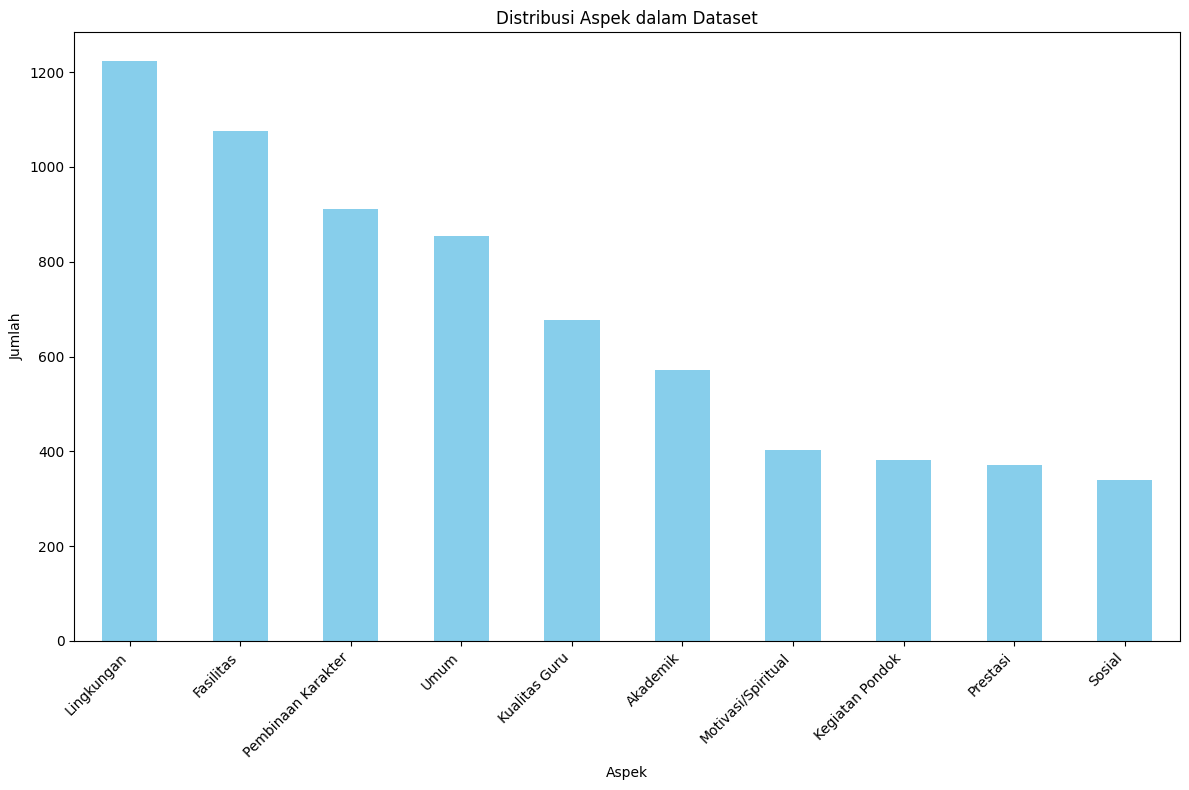

In [ ]:

# === STEP 12: Analisis Distribusi Aspek ===
print("=== STEP 12: Analisis Distribusi Aspek ===")

# Distribusi aspek
aspect_counts = df['primary_aspect'].value_counts()
print("Distribusi Aspek:")
print(aspect_counts)

plt.figure(figsize=(12, 8))
aspect_counts.plot(kind='bar', color='skyblue')
plt.title('Distribusi Aspek dalam Dataset')
plt.xlabel('Aspek')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== STEP 13: Analisis Sentimen per Aspek ===
Distribusi Sentimen per Aspek:
predicted_sentiment  negatif  netral  positif
primary_aspect                               
Akademik                  79     298      194
Fasilitas                250     340      486
Kegiatan Pondok           62      81      238
Kualitas Guru            199     180      299
Lingkungan               211     145      867
Motivasi/Spiritual        52     169      181
Pembinaan Karakter       160     420      331
Prestasi                  47     171      153
Sosial                    22     124      194
Umum                     177     374      304


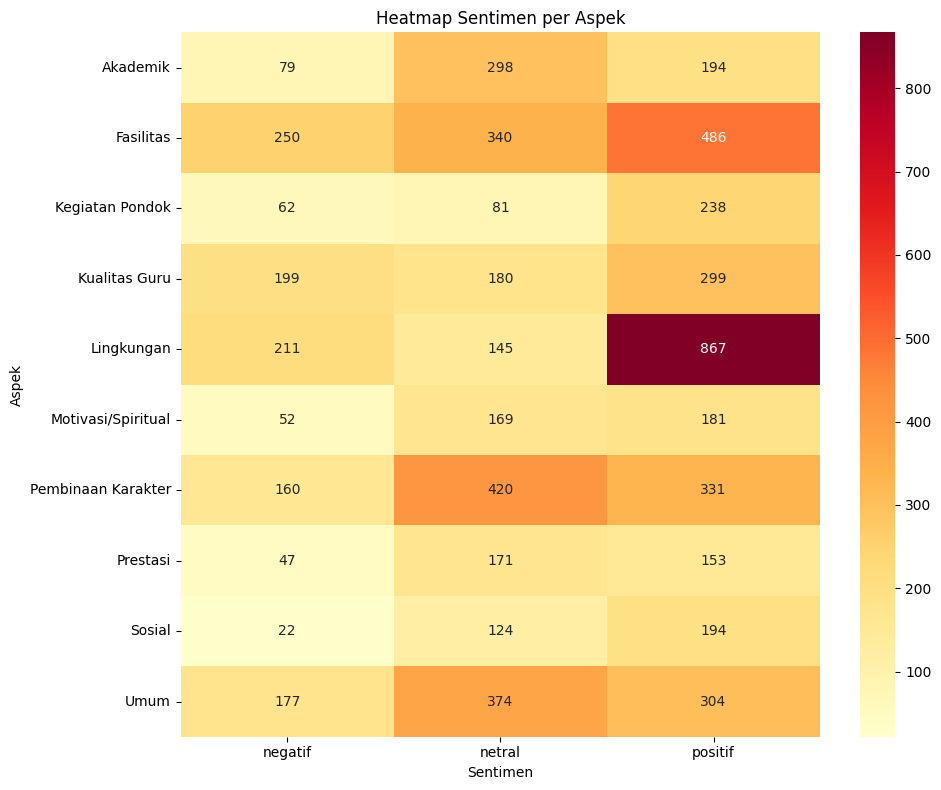

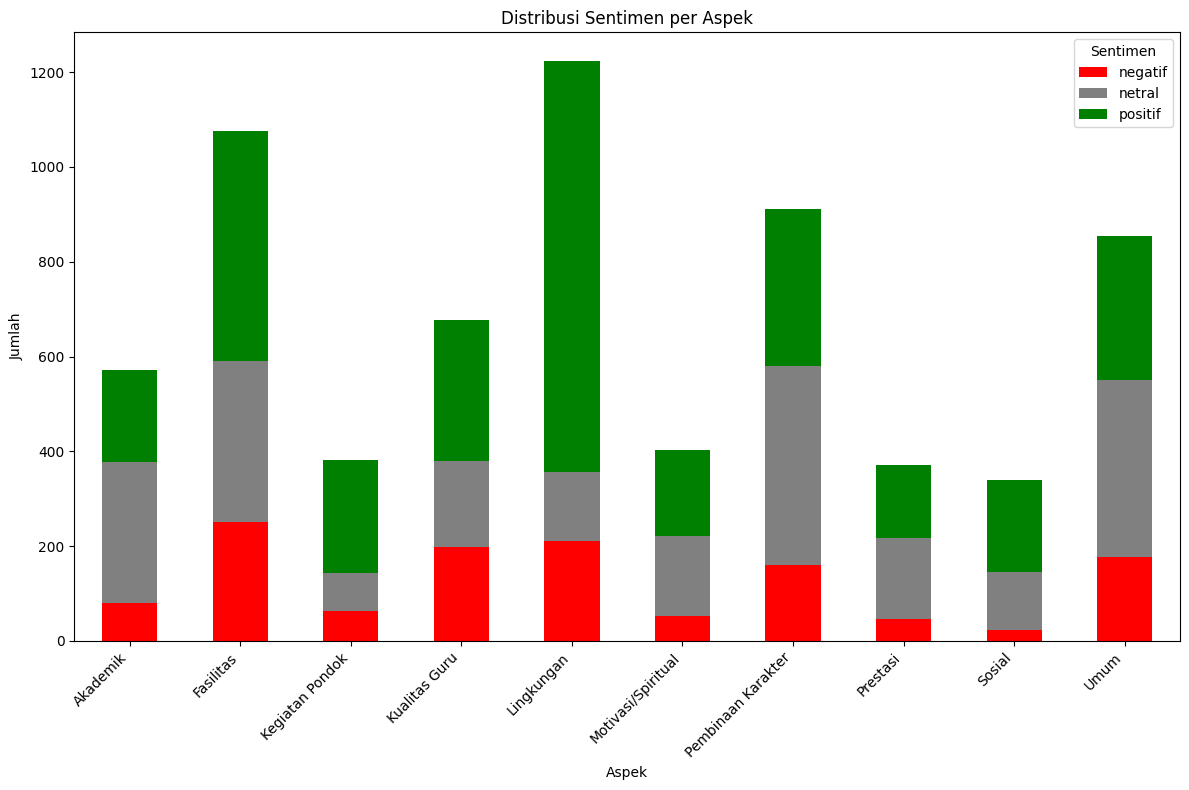

In [ ]:
# === STEP 13: Analisis Sentimen per Aspek ===
print("=== STEP 13: Analisis Sentimen per Aspek ===")

# Crosstab aspek vs sentimen
aspect_sentiment = pd.crosstab(df['primary_aspect'], df['predicted_sentiment'])
print("Distribusi Sentimen per Aspek:")
print(aspect_sentiment)

# Visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(aspect_sentiment, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap Sentimen per Aspek')
plt.xlabel('Sentimen')
plt.ylabel('Aspek')
plt.tight_layout()
plt.show()

# Visualisasi stacked bar chart
aspect_sentiment.plot(kind='bar', stacked=True, figsize=(12, 8),
                     color=['red', 'gray', 'green'])
plt.title('Distribusi Sentimen per Aspek')
plt.xlabel('Aspek')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.show()

=== STEP 14: WordCloud per Aspek ===


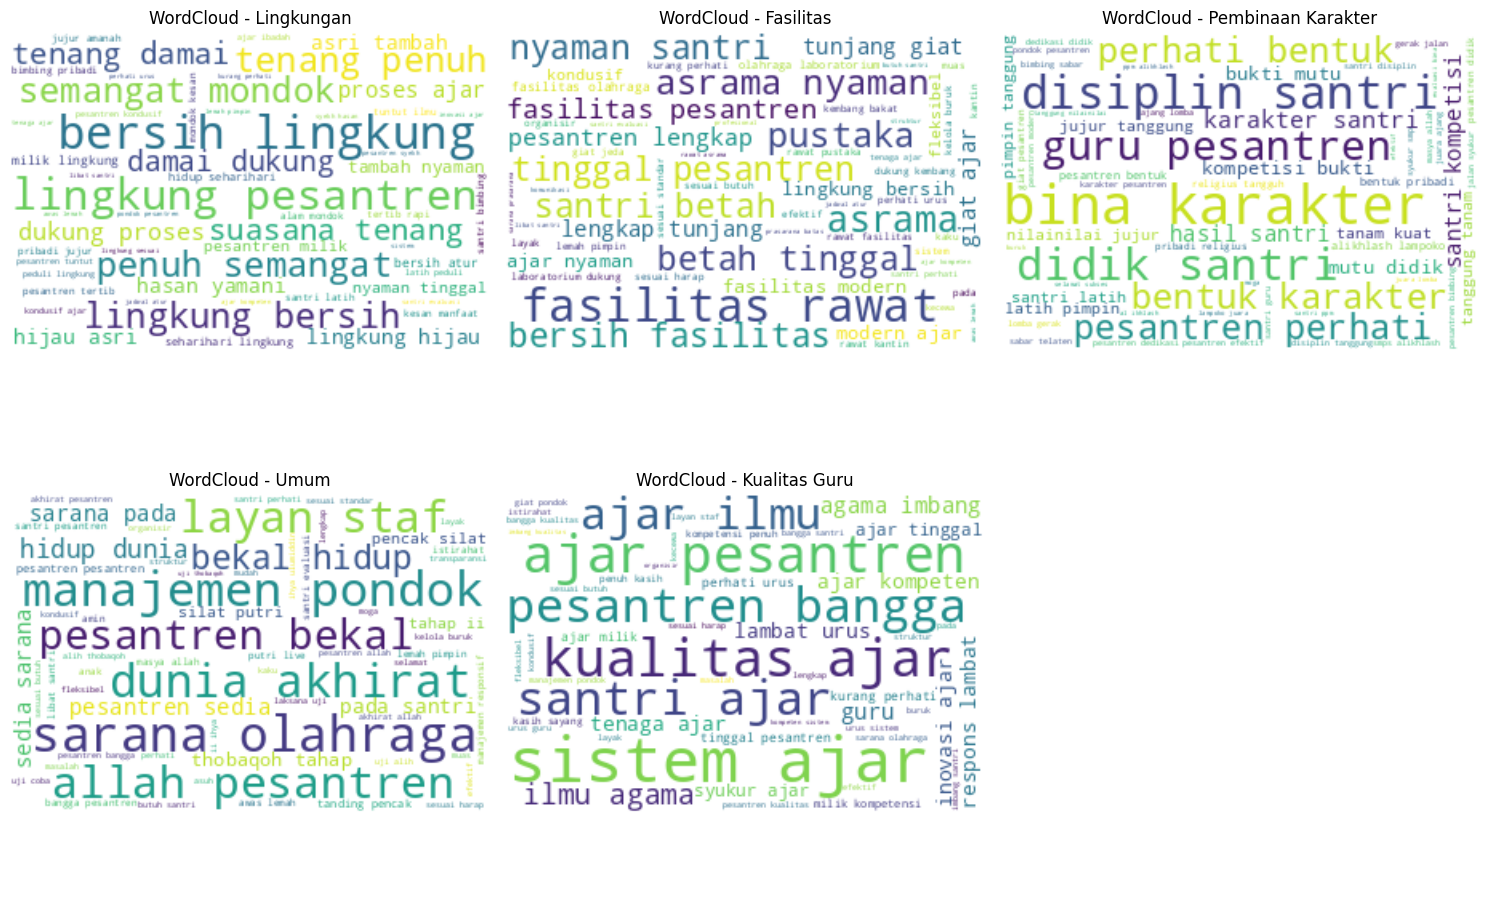

In [ ]:
# === STEP 14: WordCloud per Aspek ===
print("=== STEP 14: WordCloud per Aspek ===")

# Buat WordCloud untuk setiap aspek
aspects_to_plot = df['primary_aspect'].value_counts().head(5).index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, aspect in enumerate(aspects_to_plot):
    if i < len(axes):
        aspect_text = ' '.join(df[df['primary_aspect'] == aspect]['stemmed_text'])
        if aspect_text.strip():
            wc = WordCloud(width=300, height=200, background_color='white').generate(aspect_text)
            axes[i].imshow(wc, interpolation='bilinear')
            axes[i].set_title(f'WordCloud - {aspect}')
            axes[i].axis('off')

# Hide unused subplots
for j in range(len(aspects_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# === STEP 15: Ekstraksi Fitur TF-IDF untuk Machine Learning ===
print("=== STEP 15: Ekstraksi Fitur TF-IDF untuk Machine Learning ===")

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(df['stemmed_text'])
print("Shape matriks TF-IDF:", X_tfidf.shape)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
print(tfidf_df.head())


=== STEP 15: Ekstraksi Fitur TF-IDF untuk Machine Learning ===
Shape matriks TF-IDF: (6808, 5000)
   aaaaaamin  aaaaaamin mudah  aaaaaamin mulia  aaaaaamin uji  aaaaamin  \
0        0.0              0.0              0.0            0.0       0.0   
1        0.0              0.0              0.0            0.0       0.0   
2        0.0              0.0              0.0            0.0       0.0   
3        0.0              0.0              0.0            0.0       0.0   
4        0.0              0.0              0.0            0.0       0.0   

   aaaaamin sebentar  aaaaamin uji  aah  aah ajar  aalamiin  ...  zaman  \
0                0.0           0.0  0.0       0.0       0.0  ...    0.0   
1                0.0           0.0  0.0       0.0       0.0  ...    0.0   
2                0.0           0.0  0.0       0.0       0.0  ...    0.0   
3                0.0           0.0  0.0       0.0       0.0  ...    0.0   
4                0.0           0.0  0.0       0.0       0.0  ...    0.0   



=== STEP 16: Machine Learning untuk Prediksi Aspek ===
Akurasi Prediksi Aspek: 0.968

Classification Report - Aspek:
                    precision    recall  f1-score   support

          Akademik       0.96      0.94      0.95       114
         Fasilitas       1.00      0.99      1.00       215
   Kegiatan Pondok       0.99      0.93      0.96        76
     Kualitas Guru       0.95      0.98      0.96       136
        Lingkungan       1.00      0.96      0.98       245
Motivasi/Spiritual       0.91      0.93      0.92        81
Pembinaan Karakter       0.99      0.99      0.99       182
          Prestasi       0.99      0.93      0.96        74
            Sosial       1.00      0.93      0.96        68
              Umum       0.89      1.00      0.94       171

          accuracy                           0.97      1362
         macro avg       0.97      0.96      0.96      1362
      weighted avg       0.97      0.97      0.97      1362



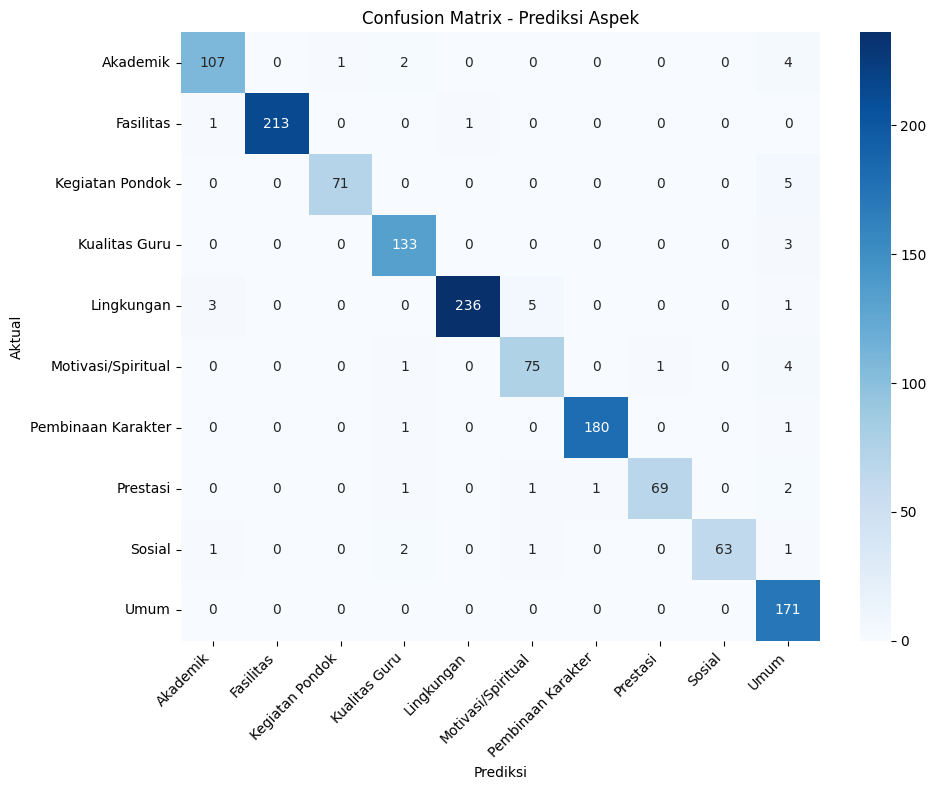

In [ ]:
# === STEP 16: Machine Learning untuk Prediksi Aspek ===
print("=== STEP 16: Machine Learning untuk Prediksi Aspek ===")

# Persiapan data untuk ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data untuk training dan testing
X_train, X_test, y_train_aspect, y_test_aspect, y_train_sentiment, y_test_sentiment = train_test_split(
    X_tfidf, df['primary_aspect'], df['predicted_sentiment'],
    test_size=0.2, random_state=42, stratify=df['primary_aspect']
)

# Model untuk prediksi aspek
aspect_model = RandomForestClassifier(n_estimators=100, random_state=42)
aspect_model.fit(X_train, y_train_aspect)

# Prediksi aspek
y_pred_aspect = aspect_model.predict(X_test)
aspect_accuracy = accuracy_score(y_test_aspect, y_pred_aspect)
print(f"Akurasi Prediksi Aspek: {aspect_accuracy:.3f}")

# Classification report untuk aspek
print("\nClassification Report - Aspek:")
print(classification_report(y_test_aspect, y_pred_aspect))

# Confusion Matrix untuk Aspek
plt.figure(figsize=(10, 8))
cm_aspect = confusion_matrix(y_test_aspect, y_pred_aspect)
aspect_labels = sorted(df['primary_aspect'].unique())
sns.heatmap(cm_aspect, annot=True, fmt='d', cmap='Blues',
            xticklabels=aspect_labels, yticklabels=aspect_labels)
plt.title("Confusion Matrix - Prediksi Aspek")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# === STEP 17: Analisis Insight ABSA ===
print("=== STEP 17: Analisis Insight ABSA ===")

# Hitung persentase sentimen per aspek
sentiment_percentage = df.groupby('primary_aspect')['predicted_sentiment'].value_counts(normalize=True).unstack(fill_value=0) * 100
print("Persentase Sentimen per Aspek:")
print(sentiment_percentage.round(2))

# Temukan aspek dengan sentimen paling positif dan negatif
positive_aspects = sentiment_percentage['positif'].sort_values(ascending=False)
negative_aspects = sentiment_percentage['negatif'].sort_values(ascending=False)

print(f"\nAspek dengan sentimen paling POSITIF:")
positive_aspects.head(3)
print(f"\nAspek dengan sentimen paling NEGATIF:")
negative_aspects.head(3)

=== STEP 17: Analisis Insight ABSA ===
Persentase Sentimen per Aspek:
predicted_sentiment  negatif  netral  positif
primary_aspect                               
Akademik               13.84   52.19    33.98
Fasilitas              23.23   31.60    45.17
Kegiatan Pondok        16.27   21.26    62.47
Kualitas Guru          29.35   26.55    44.10
Lingkungan             17.25   11.86    70.89
Motivasi/Spiritual     12.94   42.04    45.02
Pembinaan Karakter     17.56   46.10    36.33
Prestasi               12.67   46.09    41.24
Sosial                  6.47   36.47    57.06
Umum                   20.70   43.74    35.56

Aspek dengan sentimen paling POSITIF:

Aspek dengan sentimen paling NEGATIF:


,negatif
primary_aspect,
Kualitas Guru,29.351032
Fasilitas,23.234201
Umum,20.701754


In [ ]:
# === STEP 18: Function untuk Prediksi ABSA pada Teks Baru ===
print("=== STEP 18: Function untuk Prediksi ABSA pada Teks Baru ===")

def predict_absa(text, aspect_keywords, aspect_model, vectorizer, stemmer, slang_dict, stopwords_set):
    """
    Fungsi untuk memprediksi aspek dan sentimen dari teks baru
    """
    # Preprocessing
    cleaned = text_cleaning(text)
    normalized = normalize_slang(cleaned, slang_dict)
    no_stopwords = remove_stopwords_text(normalized, stopwords_set)
    stemmed = stem_text(no_stopwords, stemmer)

    # Prediksi aspek menggunakan keyword-based
    aspects = extract_aspects(text, aspect_keywords)
    primary_aspect = get_primary_aspect(aspects)

    # Prediksi sentimen
    sentiment = label_sentiment(stemmed)

    # Alternatif: prediksi aspek menggunakan ML model
    text_vectorized = vectorizer.transform([stemmed])
    ml_aspect = aspect_model.predict(text_vectorized)[0]

    return {
        'text': text,
        'aspect_keyword_based': primary_aspect,
        'aspect_ml_based': ml_aspect,
        'sentiment': sentiment,
        'processed_text': stemmed
    }

# Contoh penggunaan function
print("\n=== Contoh Prediksi ABSA ===")
sample_texts = [
    "Lingkungan pesantren itu sangat indah dan nyaman",
    "Guru di sini mengajar dengan sangat baik dan sabar",
    "Fasilitas kamar mandi kurang bersih",
    "Kegiatan mengaji di malam hari sangat bermanfaat",
    "Prestasi santri di bidang akademik sangat membanggakan"
]

for text in sample_texts:
    result = predict_absa(text, aspect_keywords, aspect_model, vectorizer,
                         stemmer, slang_dict, indo_stopwords)
    print(f"Teks: '{result['text']}'")
    print(f"Aspek (Keyword): {result['aspect_keyword_based']}")
    print(f"Aspek (ML): {result['aspect_ml_based']}")
    print(f"Sentimen: {result['sentiment']}")
    print("-" * 50)

# === STEP 19: RNN - Persiapan Data untuk Sentiment Analysis ===
print("=== STEP 19: RNN - Persiapan Data untuk Sentiment Analysis ===")


=== STEP 18: Function untuk Prediksi ABSA pada Teks Baru ===

=== Contoh Prediksi ABSA ===
Teks: 'Lingkungan pesantren itu sangat indah dan nyaman'
Aspek (Keyword): Lingkungan
Aspek (ML): Lingkungan
Sentimen: positif
--------------------------------------------------
Teks: 'Guru di sini mengajar dengan sangat baik dan sabar'
Aspek (Keyword): Pembinaan Karakter
Aspek (ML): Kualitas Guru
Sentimen: positif
--------------------------------------------------
Teks: 'Fasilitas kamar mandi kurang bersih'
Aspek (Keyword): Fasilitas
Aspek (ML): Fasilitas
Sentimen: netral
--------------------------------------------------
Teks: 'Kegiatan mengaji di malam hari sangat bermanfaat'
Aspek (Keyword): Kegiatan Pondok
Aspek (ML): Kegiatan Pondok
Sentimen: positif
--------------------------------------------------
Teks: 'Prestasi santri di bidang akademik sangat membanggakan'
Aspek (Keyword): Prestasi
Aspek (ML): Prestasi
Sentimen: positif
--------------------------------------------------
=== STEP 19: RN

In [ ]:
# === STEP 19: RNN - Persiapan Data untuk Sentiment Analysis ===
print("=== STEP 19: RNN - Persiapan Data untuk Sentiment Analysis ===")

max_features = 5000
max_len = 100  # Batasi panjang sequence untuk efisiensi

# Tokenizer untuk RNN
tokenizer_rnn = Tokenizer(num_words=max_features, split=' ')
tokenizer_rnn.fit_on_texts(df['stemmed_text'].values)
X_rnn = tokenizer_rnn.texts_to_sequences(df['stemmed_text'].values)
X_rnn = pad_sequences(X_rnn, maxlen=max_len)

# Label encoding untuk sentiment
label_encoder = LabelEncoder()
y_sentiment_rnn = label_encoder.fit_transform(df['predicted_sentiment'])

print("Shape data RNN setelah tokenisasi dan padding:", X_rnn.shape)
print("Classes sentiment:", label_encoder.classes_)

# Distribusi sentiment sebelum balancing
print("\nDistribusi Sentiment Sebelum Balancing:")
sentiment_counts_before = pd.Series(y_sentiment_rnn).value_counts().sort_index()
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {sentiment_counts_before[i]}")

=== STEP 19: RNN - Persiapan Data untuk Sentiment Analysis ===
Shape data RNN setelah tokenisasi dan padding: (6808, 100)
Classes sentiment: ['negatif' 'netral' 'positif']

Distribusi Sentiment Sebelum Balancing:
negatif: 1259
netral: 2302
positif: 3247


In [ ]:
#  === STEP 20: RNN - Model Pertama (Sebelum SMOTE) ===
print("=== STEP 20: RNN - Model Pertama (Sebelum SMOTE) ===")

# Split data
X_train_rnn1, X_test_rnn1, y_train_rnn1, y_test_rnn1 = train_test_split(
    X_rnn, y_sentiment_rnn, test_size=0.2, random_state=42, stratify=y_sentiment_rnn
)

print("Shape data training RNN (sebelum SMOTE):", X_train_rnn1.shape)
print("Shape data testing RNN (sebelum SMOTE):", X_test_rnn1.shape)

# Arsitektur RNN Model 1
embedding_dim = 128
lstm_out = 196

model_rnn1 = Sequential()
model_rnn1.add(Embedding(max_features, embedding_dim, input_length=max_len))
model_rnn1.add(Dropout(0.5))
model_rnn1.add(LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2))
model_rnn1.add(Dense(3, activation='softmax'))
model_rnn1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Build model secara eksplisit agar summary bisa tampil
model_rnn1.build(input_shape=(None, max_len))  # None untuk batch size

print("Arsitektur RNN Model 1 (Sebelum SMOTE):")
model_rnn1.summary()

# Training RNN Model 1
print("\nTraining RNN Model 1...")
batch_size = 32
history1 = model_rnn1.fit(X_train_rnn1, y_train_rnn1, epochs=5, batch_size=batch_size,
                         validation_split=0.1, verbose=1)

# Evaluasi RNN Model 1
loss1, accuracy1 = model_rnn1.evaluate(X_test_rnn1, y_test_rnn1, verbose=0)
print(f"RNN Model 1 - Accuracy: {accuracy1:.4f}")

# Prediksi dan classification report
y_pred_rnn1 = model_rnn1.predict(X_test_rnn1)
y_pred_rnn1_classes = np.argmax(y_pred_rnn1, axis=1)

print("\nClassification Report RNN Model 1 (Sebelum SMOTE):")
print(classification_report(y_test_rnn1, y_pred_rnn1_classes, target_names=label_encoder.classes_))


=== STEP 20: RNN - Model Pertama (Sebelum SMOTE) ===
Shape data training RNN (sebelum SMOTE): (5446, 100)
Shape data testing RNN (sebelum SMOTE): (1362, 100)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Arsitektur RNN Model 1 (Sebelum SMOTE):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 196)            │       254,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 895,391 (3.42 MB)

 Trainable params: 895,391 (3.42 MB)

 Non-trainable params: 0 (0.00 B)


Training RNN Model 1...
Epoch 1/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 89s 546ms/step - accuracy: 0.6035 - loss: 0.8268 - val_accuracy: 0.9303 - val_loss: 0.2275
Epoch 2/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 141s 545ms/step - accuracy: 0.9364 - loss: 0.1827 - val_accuracy: 0.9303 - val_loss: 0.1838
Epoch 3/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 141s 540ms/step - accuracy: 0.9433 - loss: 0.1505 - val_accuracy: 0.9321 - val_loss: 0.1550
Epoch 4/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 141s 532ms/step - accuracy: 0.9559 - loss: 0.1230 - val_accuracy: 0.9266 - val_loss: 0.1608
Epoch 5/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 84s 543ms/step - accuracy: 0.9568 - loss: 0.1129 - val_accuracy: 0.9303 - val_loss: 0.1699
RNN Model 1 - Accuracy: 0.9501
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step

Classification Report RNN Model 1 (Sebelum SMOTE):
              precision    recall  f1-score   support

     negatif       0.97      0.94      0.96       252
      netral       0.92      0.95      0.94       460
     positif       0.96      0.95   

=== STEP 21: Visualisasi RNN Model 1 ===


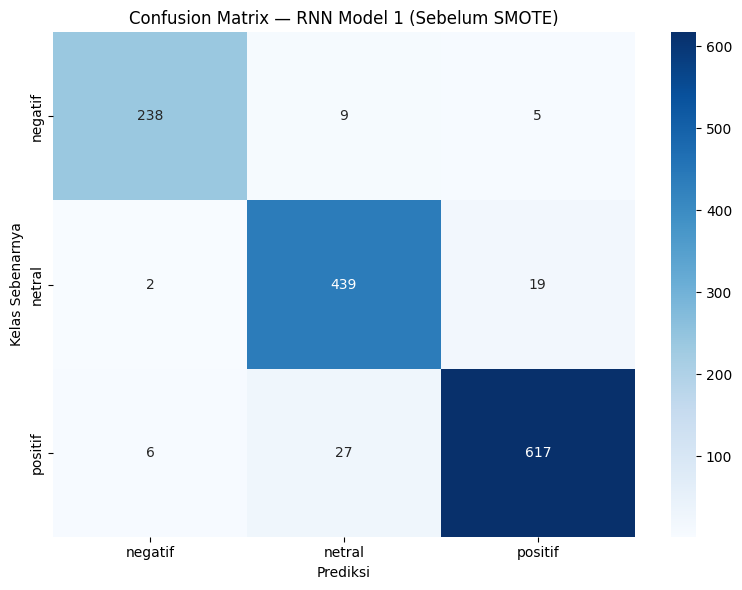

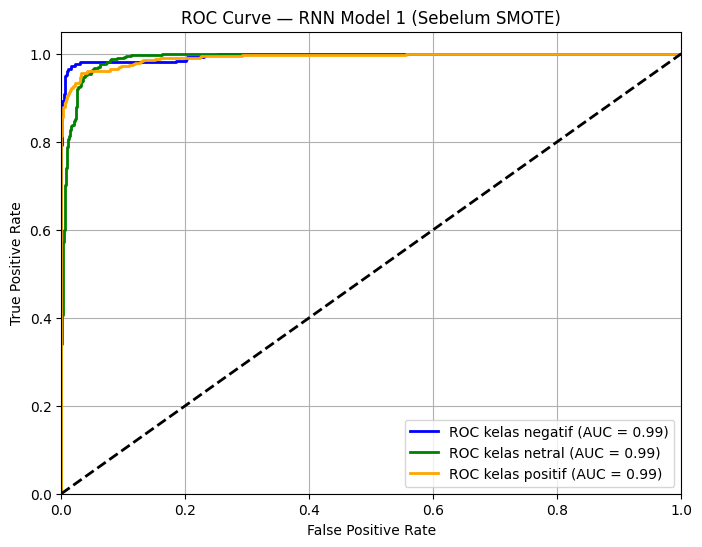

In [ ]:
# === STEP 21: Visualisasi RNN Model 1 ===
print("=== STEP 21: Visualisasi RNN Model 1 ===")

# Confusion Matrix RNN Model 1
plt.figure(figsize=(8, 6))
cm1 = confusion_matrix(y_test_rnn1, y_pred_rnn1_classes)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix — RNN Model 1 (Sebelum SMOTE)")
plt.xlabel("Prediksi")
plt.ylabel("Kelas Sebenarnya")
plt.tight_layout()
plt.show()

# ROC Curve RNN Model 1
n_classes = len(label_encoder.classes_)
y_test_bin1 = label_binarize(y_test_rnn1, classes=range(n_classes))

fpr1, tpr1, roc_auc1 = {}, {}, {}
colors = cycle(['blue', 'green', 'orange'])

plt.figure(figsize=(8,6))
for i, color in zip(range(n_classes), colors):
    fpr1[i], tpr1[i], _ = roc_curve(y_test_bin1[:, i], y_pred_rnn1[:, i])
    roc_auc1[i] = auc(fpr1[i], tpr1[i])
    plt.plot(fpr1[i], tpr1[i], color=color, lw=2,
             label=f'ROC kelas {label_encoder.classes_[i]} (AUC = {roc_auc1[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — RNN Model 1 (Sebelum SMOTE)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

=== STEP 22: SMOTE untuk Balancing Data ===
Shape data training setelah SMOTE: (7791, 100)

Distribusi Sentiment Setelah SMOTE:
negatif: 2597
netral: 2597
positif: 2597


<Figure size 1000x600 with 0 Axes>

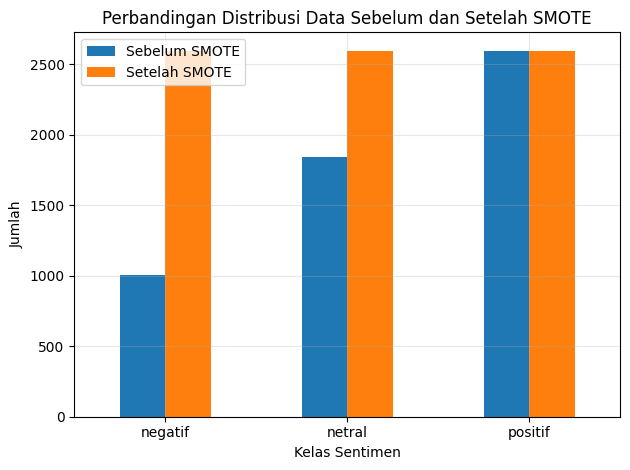

In [ ]:
# === STEP 22: SMOTE untuk Balancing Data ===
print("=== STEP 22: SMOTE untuk Balancing Data ===")

# Gunakan SMOTE pada data training
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rnn1, y_train_rnn1)

print("Shape data training setelah SMOTE:", X_train_smote.shape)

# Distribusi setelah SMOTE
print("\nDistribusi Sentiment Setelah SMOTE:")
sentiment_counts_after = pd.Series(y_train_smote).value_counts().sort_index()
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {sentiment_counts_after[i]}")

# Visualisasi perbandingan distribusi
original_counts = pd.Series(y_train_rnn1).value_counts().sort_index()
smote_counts = pd.Series(y_train_smote).value_counts().sort_index()

df_comparison = pd.DataFrame({
    'Sebelum SMOTE': original_counts,
    'Setelah SMOTE': smote_counts
})

plt.figure(figsize=(10, 6))
df_comparison.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Perbandingan Distribusi Data Sebelum dan Setelah SMOTE')
plt.xlabel('Kelas Sentimen')
plt.ylabel('Jumlah')
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# === STEP 23: RNN - Model Kedua (Setelah SMOTE) ===
print("=== STEP 23: RNN - Model Kedua (Setelah SMOTE) ===")

# Arsitektur RNN Model 2 (sama dengan model 1)
model_rnn2 = Sequential()
model_rnn2.add(Embedding(max_features, embedding_dim, input_length=max_len))
model_rnn2.add(Dropout(0.5))
model_rnn2.add(LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2))
model_rnn2.add(Dense(3, activation='softmax'))
model_rnn2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Build model secara eksplisit agar summary bisa tampil
model_rnn2.build(input_shape=(None, max_len))  # None untuk batch size

print("Arsitektur RNN Model 2 (Setelah SMOTE):")
model_rnn2.summary()

# Training RNN Model 2 dengan data yang sudah di-SMOTE
print("\nTraining RNN Model 2...")
history2 = model_rnn2.fit(X_train_smote, y_train_smote, epochs=5, batch_size=batch_size,
                         validation_split=0.1, verbose=1)

# Evaluasi RNN Model 2 (menggunakan test set yang sama)
loss2, accuracy2 = model_rnn2.evaluate(X_test_rnn1, y_test_rnn1, verbose=0)
print(f"RNN Model 2 - Accuracy: {accuracy2:.4f}")

# Prediksi dan classification report
y_pred_rnn2 = model_rnn2.predict(X_test_rnn1)
y_pred_rnn2_classes = np.argmax(y_pred_rnn2, axis=1)

print("\nClassification Report RNN Model 2 (Setelah SMOTE):")
print(classification_report(y_test_rnn1, y_pred_rnn2_classes, target_names=label_encoder.classes_))


=== STEP 23: RNN - Model Kedua (Setelah SMOTE) ===
Arsitektur RNN Model 2 (Setelah SMOTE):


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 196)            │       254,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 895,391 (3.42 MB)

 Trainable params: 895,391 (3.42 MB)

 Non-trainable params: 0 (0.00 B)


Training RNN Model 2...
Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 127s 554ms/step - accuracy: 0.6613 - loss: 0.7625 - val_accuracy: 0.8013 - val_loss: 0.6487
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 138s 538ms/step - accuracy: 0.9080 - loss: 0.2529 - val_accuracy: 0.7577 - val_loss: 0.8805
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 142s 538ms/step - accuracy: 0.9245 - loss: 0.2225 - val_accuracy: 0.7321 - val_loss: 0.9983
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 142s 540ms/step - accuracy: 0.9317 - loss: 0.1842 - val_accuracy: 0.7590 - val_loss: 0.8927
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 154s 596ms/step - accuracy: 0.9361 - loss: 0.1758 - val_accuracy: 0.7346 - val_loss: 1.0265
RNN Model 2 - Accuracy: 0.9413
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step

Classification Report RNN Model 2 (Setelah SMOTE):
              precision    recall  f1-score   support

     negatif       0.92      0.96      0.94       252
      netral       0.94      0.92      0.93       460
     positif       0.96      0.95

=== STEP 24: Visualisasi RNN Model 2 ===


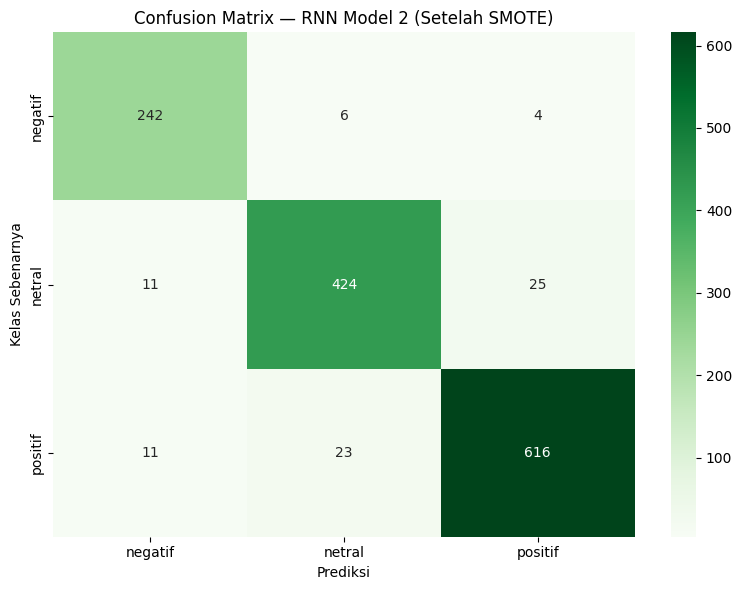

In [ ]:
# === STEP 24: Visualisasi RNN Model 2 ===
print("=== STEP 24: Visualisasi RNN Model 2 ===")

# Confusion Matrix RNN Model 2
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test_rnn1, y_pred_rnn2_classes)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix — RNN Model 2 (Setelah SMOTE)")
plt.xlabel("Prediksi")
plt.ylabel("Kelas Sebenarnya")
plt.tight_layout()
plt.show()

# ROC Curve RNN Model 2
fpr2, tpr2, roc_auc2 = {}, {}, {}

plt.figure(figsize=(8,6))
for i, color in zip(range(n_classes), colors):
    fpr2[i], tpr2[i], _ = roc_curve(y_test_bin1[:, i], y_pred_rnn2[:, i])
    roc_auc2[i] = auc(fpr2[i], tpr2[i])
    plt.plot(fpr2[i], tpr2[i], color=color, lw=2,
             label=f'ROC kelas {label_encoder.classes_[i]} (AUC = {roc_auc2[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — RNN Model 2 (Setelah SMOTE)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# === STEP 25: Perbandingan Kedua Model RNN ===
print("=== STEP 25: Perbandingan Kedua Model RNN ===")

# Perbandingan akurasi
comparison_data = {
    'Model': ['RNN Sebelum SMOTE', 'RNN Setelah SMOTE'],
    'Accuracy': [accuracy1, accuracy2],
    'Training Data Size': [len(X_train_rnn1), len(X_train_smote)]
}

comparison_df = pd.DataFrame(comparison_data)
print("Perbandingan Performa Model:")
print(comparison_df)

# Visualisasi perbandingan akurasi
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'],
               color=['skyblue', 'lightgreen'], alpha=0.8)
plt.title('Perbandingan Akurasi RNN Sebelum dan Setelah SMOTE')
plt.ylabel('Accuracy')
plt.ylim([0, 1])

# Tambahkan nilai akurasi di atas bar
for bar, acc in zip(bars, comparison_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Perbandingan Training History
plt.figure(figsize=(15, 5))

# Subplot 1: Training Accuracy
plt.subplot(1, 3, 1)
plt.plot(history1.history['accuracy'], label='Model 1 (Sebelum SMOTE)', color='blue')
plt.plot(history2.history['accuracy'], label='Model 2 (Setelah SMOTE)', color='green')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Training Loss
plt.subplot(1, 3, 2)
plt.plot(history1.history['loss'], label='Model 1 (Sebelum SMOTE)', color='blue')
plt.plot(history2.history['loss'], label='Model 2 (Setelah SMOTE)', color='green')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Validation Accuracy
plt.subplot(1, 3, 3)
plt.plot(history1.history['val_accuracy'], label='Model 1 (Sebelum SMOTE)', color='blue')
plt.plot(history2.history['val_accuracy'], label='Model 2 (Setelah SMOTE)', color='green')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Perbandingan Confusion Matrix side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix Model 1
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax1)
ax1.set_title("Confusion Matrix — RNN Sebelum SMOTE")
ax1.set_xlabel("Prediksi")
ax1.set_ylabel("Kelas Sebenarnya")

# Confusion Matrix Model 2
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax2)
ax2.set_title("Confusion Matrix — RNN Setelah SMOTE")
ax2.set_xlabel("Prediksi")
ax2.set_ylabel("Kelas Sebenarnya")

plt.tight_layout()
plt.show()

# Perbandingan AUC Score
print("\nPerbandingan AUC Score per Kelas:")
auc_comparison = pd.DataFrame({
    'Kelas': label_encoder.classes_,
    'AUC Sebelum SMOTE': [roc_auc1[i] for i in range(n_classes)],
    'AUC Setelah SMOTE': [roc_auc2[i] for i in range(n_classes)]
})
print(auc_comparison)

# Visualisasi perbandingan AUC
plt.figure(figsize=(10, 6))
x = np.arange(len(label_encoder.classes_))
width = 0.35

plt.bar(x - width/2, [roc_auc1[i] for i in range(n_classes)], width,
        label='Sebelum SMOTE', color='skyblue', alpha=0.8)
plt.bar(x + width/2, [roc_auc2[i] for i in range(n_classes)], width,
        label='Setelah SMOTE', color='lightgreen', alpha=0.8)

plt.xlabel('Kelas Sentimen')
plt.ylabel('AUC Score')
plt.title('Perbandingan AUC Score per Kelas')
plt.xticks(x, label_encoder.classes_)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# === STEP 26: Export Hasil ABSA ===
print("=== STEP 26: Export Hasil ABSA ===")

# Buat dataframe hasil akhir
result_df = df[['kalimat', 'primary_aspect', 'predicted_sentiment']].copy()
result_df.columns = ['Teks_Asli', 'Aspek', 'Sentimen']

# Tambahkan prediksi dari kedua model RNN
# Prediksi untuk seluruh dataset
X_full_rnn = tokenizer_rnn.texts_to_sequences(df['stemmed_text'].values)
X_full_rnn = pad_sequences(X_full_rnn, maxlen=max_len)

pred_model1 = model_rnn1.predict(X_full_rnn)
pred_model2 = model_rnn2.predict(X_full_rnn)

result_df['Sentimen_RNN_SebelumSMOTE'] = [label_encoder.classes_[np.argmax(pred)] for pred in pred_model1]
result_df['Sentimen_RNN_SetelahSMOTE'] = [label_encoder.classes_[np.argmax(pred)] for pred in pred_model2]

# Export ke Excel
result_df.to_excel('/content/hasil_absa_pesantren_lengkap.xlsx', index=False)
print("Hasil ABSA lengkap telah disimpan ke 'hasil_absa_pesantren_lengkap.xlsx'")

# === STEP 27: Statistik Akhir ===
print("=== STEP 27: Statistik Akhir ===")

print(f"Total data: {len(df)}")
print(f"Total aspek unik: {df['primary_aspect'].nunique()}")
print(f"Total sentimen unik: {df['predicted_sentiment'].nunique()}")
print(f"Akurasi prediksi aspek: {aspect_accuracy:.3f}")
print(f"Akurasi RNN sebelum SMOTE: {accuracy1:.4f}")
print(f"Akurasi RNN setelah SMOTE: {accuracy2:.4f}")
print(f"Peningkatan akurasi: {(accuracy2-accuracy1)*100:.2f}%")

print("\nDistribusi akhir:")
print("Aspek:")
print(df['primary_aspect'].value_counts())
print("\nSentimen:")
print(df['predicted_sentiment'].value_counts())

# Analisis dampak SMOTE
print(f"\n=== ANALISIS DAMPAK SMOTE ===")
if accuracy2 > accuracy1:
    print(f"✅ SMOTE meningkatkan akurasi sebesar {(accuracy2-accuracy1)*100:.2f}%")
else:
    print(f"❌ SMOTE menurunkan akurasi sebesar {(accuracy1-accuracy2)*100:.2f}%")

# Analisis per kelas
print("\nDampak SMOTE per kelas:")
for i, class_name in enumerate(label_encoder.classes_):
    auc_diff = roc_auc2[i] - roc_auc1[i]
    if auc_diff > 0:
        print(f"✅ {class_name}: AUC meningkat {auc_diff:.3f}")
    else:
        print(f"❌ {class_name}: AUC menurun {abs(auc_diff):.3f}")

print("\n=== ABSA DENGAN PERBANDINGAN RNN SELESAI ===")
print("Sistem ABSA dengan perbandingan RNN sebelum dan setelah SMOTE telah berhasil dibuat!")
print("Semua visualisasi dan analisis perbandingan telah ditampilkan.")
print("Anda dapat melihat perbedaan performa kedua model dalam grafik di atas.")

=== STEP 26: Export Hasil ABSA ===
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step
Hasil ABSA lengkap telah disimpan ke 'hasil_absa_pesantren_lengkap.xlsx'
=== STEP 27: Statistik Akhir ===
Total data: 6808
Total aspek unik: 10
Total sentimen unik: 3
Akurasi prediksi aspek: 0.968
Akurasi RNN sebelum SMOTE: 0.9501
Akurasi RNN setelah SMOTE: 0.9413
Peningkatan akurasi: -0.88%

Distribusi akhir:
Aspek:
primary_aspect
Lingkungan            1223
Fasilitas             1076
Pembinaan Karakter     911
Umum                   855
Kualitas Guru          678
Akademik               571
Motivasi/Spiritual     402
Kegiatan Pondok        381
Prestasi               371
Sosial                 340
Name: count, dtype: int64

Sentimen:
predicted_sentiment
positif    3247
netral     2302
negatif    1259
Name: count, dtype: int64

=== ANALISIS DAMPAK SMOTE ===
❌ SMOTE menurunkan akurasi sebesar 0.88%

Dampak SMOTE per kelas:
❌ negatif: AUC menurun 0.003
❌ netral: AUC men